# Optimizer and Learning-Rate Schedule Interactions for High-Dimensional Genomic Classification
### A Benchmark Study on TCGA Pan-Cancer Gene Expression Data

**ASDS 6304 Optimization Methods · Group 5 · Spring 2026 · UT Arlington**

---

**Research questions**

1. Which optimizer wins on regularized logistic regression in 20K-dim feature space  first-order (GD, SGD, Adam) or quasi-Newton (L-BFGS)?
2. Does learning-rate schedule choice matter as much as optimizer choice?
3. How does the optimizer × schedule interaction affect Lasso gene selection?
4. Under a clinical budget of *k* genes, which subset maximises class separability? (LP formulation)

**Design.** 6 optimizers × 4 LR schedules × 2 regularizers × 3 seeds = **144 model fits** on a single shared linear architecture.

**Dataset.** TCGA Pan-Cancer RNA-Seq, 33 cancer types. We use a 15-per-class stratified subset (495 samples) for the report; the same code scales to the full 10,535-sample matrix.

## 0  Setup

In [ ]:
import os, time, json, warnings
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)
from scipy.optimize import linprog
from scipy.stats import f_oneway

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#f8f9fa",
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   13,
    "axes.labelsize":   11,
})

DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RES_DIR = Path("results"); RES_DIR.mkdir(exist_ok=True)

print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {DEVICE}")
print(f"Results  : {RES_DIR.resolve()}")

PyTorch  : 2.10.0+cu128
Device   : cuda
Results  : /content/results


---
## 1  Data Loading and Preparation

We look for the small pre-built CSVs first; if absent, we build the 495-sample subset directly from the
UCSC Xena Toil mirror. Set `USE_FULL_DATA = True` to run on the complete 10,535-sample matrix.

In [ ]:
# ── Load real TCGA data and rebuild the 495-sample subset ──────
print("Downloading expression matrix (~700MB, takes 5-8 min)...")
expr_url = "https://toil-xena-hub.s3.us-east-1.amazonaws.com/download/tcga_RSEM_Hugo_norm_count.gz"
expr_full = pd.read_csv(expr_url, sep="\t", index_col=0).T   # samples × genes
print(f"Expression: {expr_full.shape}")

# Align with labels
common = expr_full.index.intersection(pheno.index)
expr_full = expr_full.loc[common]
pheno_aligned = pheno.loc[common]

# Stratified 15-per-class subset
rng = np.random.default_rng(42)
keep = []
for cls, idx in pheno_aligned.groupby("_primary_disease").groups.items():
    sel = rng.choice(list(idx), size=min(15, len(idx)), replace=False)
    keep.extend(sel)

expr_small  = expr_full.loc[keep].astype(np.float32)
labels_small = pheno_aligned.loc[keep][["_primary_disease"]]

# Save so next run skips the download
expr_small.to_csv("/content/tcga_small_expression.csv")
labels_small.to_csv("/content/tcga_small_labels.csv")
print(f"Saved. Expression: {expr_small.shape}, Labels: {labels_small.shape}")
print(labels_small["_primary_disease"].value_counts().head(5))

# Reset the variables the notebook uses
expr_raw   = expr_small
labels_raw = labels_small
print("\nDone — now restart from the Feature Cleaning cell onwards.")

Expression: (10535, 58581)
Saved. Expression: (495, 58581), Labels: (495, 1)
_primary_disease
acute myeloid leukemia          15
adrenocortical cancer           15
bladder urothelial carcinoma    15
brain lower grade glioma        15
breast invasive carcinoma       15
Name: count, dtype: int64

Done — now restart from the Feature Cleaning cell onwards.


In [ ]:
# Feature cleaning
print(f"Starting genes : {expr_raw.shape[1]:,}")

expr_raw = expr_raw.loc[:, ~expr_raw.columns.duplicated()]
print(f"After de-dup    : {expr_raw.shape[1]:,}")

variances = expr_raw.var()
expr_raw  = expr_raw.loc[:, variances >= 0.01]
print(f"After var ≥ 0.01: {expr_raw.shape[1]:,}")

variances = expr_raw.var().sort_values(ascending=False)
top_genes = variances.head(N_TOP_GENES).index
expr_raw  = expr_raw[top_genes]
print(f"Top {N_TOP_GENES:,} by variance kept → final shape: {expr_raw.shape}")

Starting genes : 58,581
After de-dup    : 58,581
After var ≥ 0.01: 50,025
Top 20,000 by variance kept → final shape: (495, 20000)


In [ ]:
# Align samples between expression and labels, encode classes
common = expr_raw.index.intersection(labels_raw.index)
expr_raw   = expr_raw.loc[common]
labels_raw = labels_raw.loc[common]

le = LabelEncoder()
y = le.fit_transform(labels_raw["_primary_disease"])
X = expr_raw.values.astype(np.float32)

n_classes = len(le.classes_)
print(f"X : {X.shape}")
print(f"y : {y.shape}")
print(f"Classes : {n_classes}")

X : (495, 20000)
y : (495,)
Classes : 33


In [ ]:
# Stratified 60/20/20 split, then StandardScaler fit on train only
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.25, random_state=42, stratify=y_tmp)

scaler  = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train).astype(np.float32)
X_val   = scaler.transform(X_val).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

gene_names = expr_raw.columns.tolist()
n_features = X_train.shape[1]

print(f"Train : {X_train.shape}  ({len(X_train)/len(X)*100:.0f}%)")
print(f"Val   : {X_val.shape}   ({len(X_val)/len(X)*100:.0f}%)")
print(f"Test  : {X_test.shape}  ({len(X_test)/len(X)*100:.0f}%)")
print(f"Train mean={X_train.mean():.3f}  std={X_train.std():.3f}")

Train : (297, 20000)  (60%)
Val   : (99, 20000)   (20%)
Test  : (99, 20000)  (20%)
Train mean=0.000  std=1.000


---
## 2  Exploratory Feature Analysis

Four plots that justify the preprocessing and the classification setup: variance distribution, gene-gene correlation, PCA scree, and 2-D PCA by cancer type.

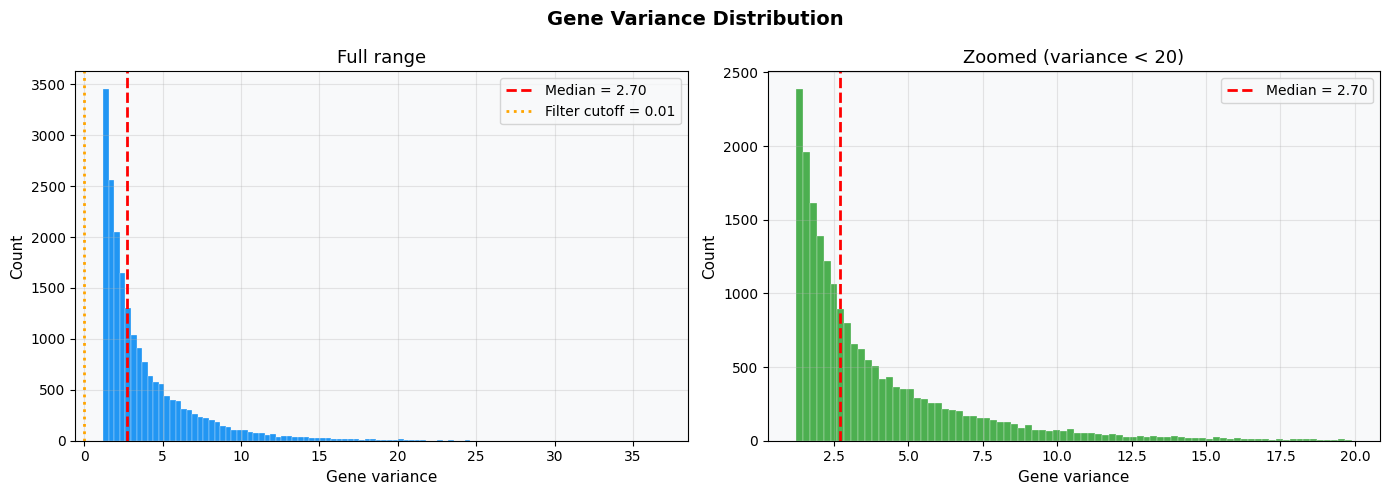

Heavy right-skew — most genes carry no signal; variance filter is justified.


In [ ]:
# 2A · Gene variance histogram
var_series = pd.Series(variances.values[:N_TOP_GENES])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Gene Variance Distribution", fontsize=14, fontweight="bold")

axes[0].hist(var_series, bins=100, color="#2196F3", edgecolor="white", linewidth=0.2)
axes[0].axvline(var_series.median(), color="red",   linestyle="--", lw=2, label=f"Median = {var_series.median():.2f}")
axes[0].axvline(0.01,                color="orange",linestyle=":",  lw=2, label="Filter cutoff = 0.01")
axes[0].set(xlabel="Gene variance", ylabel="Count", title="Full range"); axes[0].legend()

axes[1].hist(var_series[var_series < 20], bins=80, color="#4CAF50", edgecolor="white", linewidth=0.2)
axes[1].axvline(var_series.median(), color="red", linestyle="--", lw=2, label=f"Median = {var_series.median():.2f}")
axes[1].set(xlabel="Gene variance", ylabel="Count", title="Zoomed (variance < 20)"); axes[1].legend()

plt.tight_layout()
plt.savefig(RES_DIR / "eda_variance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Heavy right-skew — most genes carry no signal; variance filter is justified.")

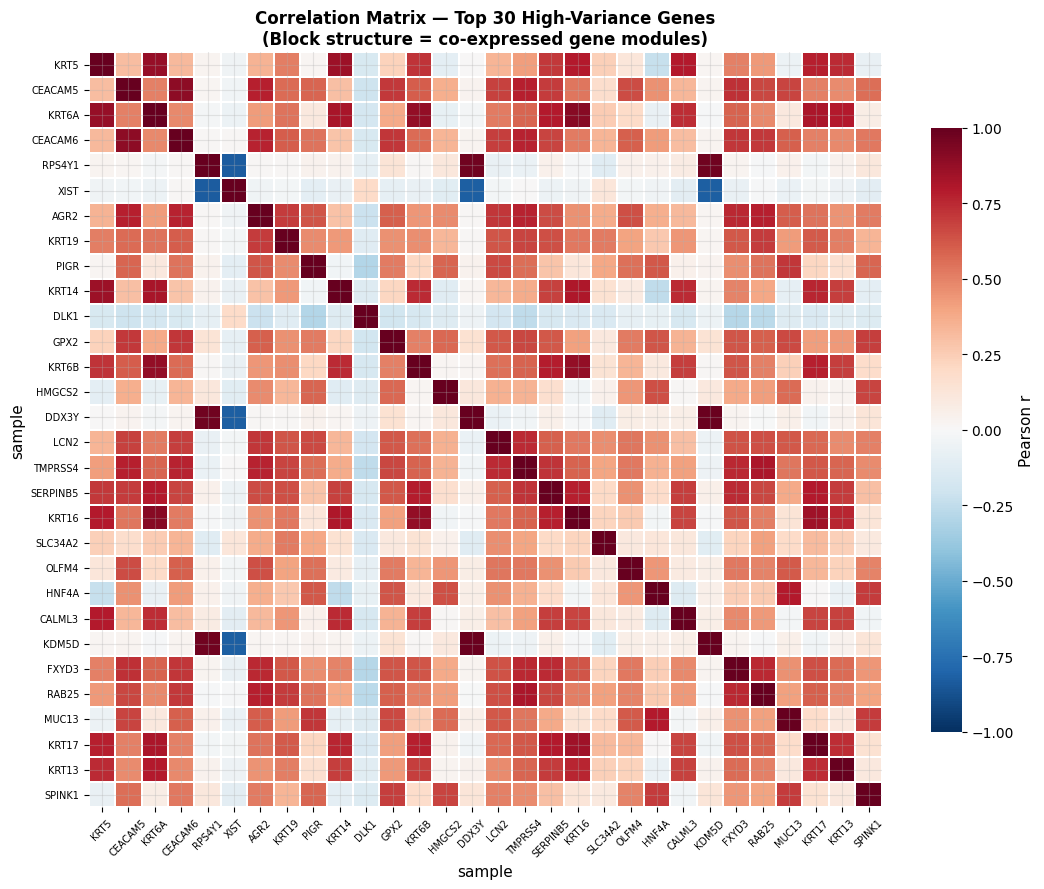

In [ ]:
# 2B · Correlation heatmap of the top 30 most variable genes
top30 = variances.head(30).index
corr  = expr_raw[top30].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, ax=ax, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            xticklabels=[g[:12] for g in top30],
            yticklabels=[g[:12] for g in top30],
            linewidths=0.3, cbar_kws={"shrink": 0.8, "label": "Pearson r"})
ax.set_title("Correlation Matrix — Top 30 High-Variance Genes\n(Block structure = co-expressed gene modules)",
             fontsize=12, fontweight="bold")
ax.tick_params(axis="x", rotation=45, labelsize=7)
ax.tick_params(axis="y", rotation=0,  labelsize=7)
plt.tight_layout()
plt.savefig(RES_DIR / "eda_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

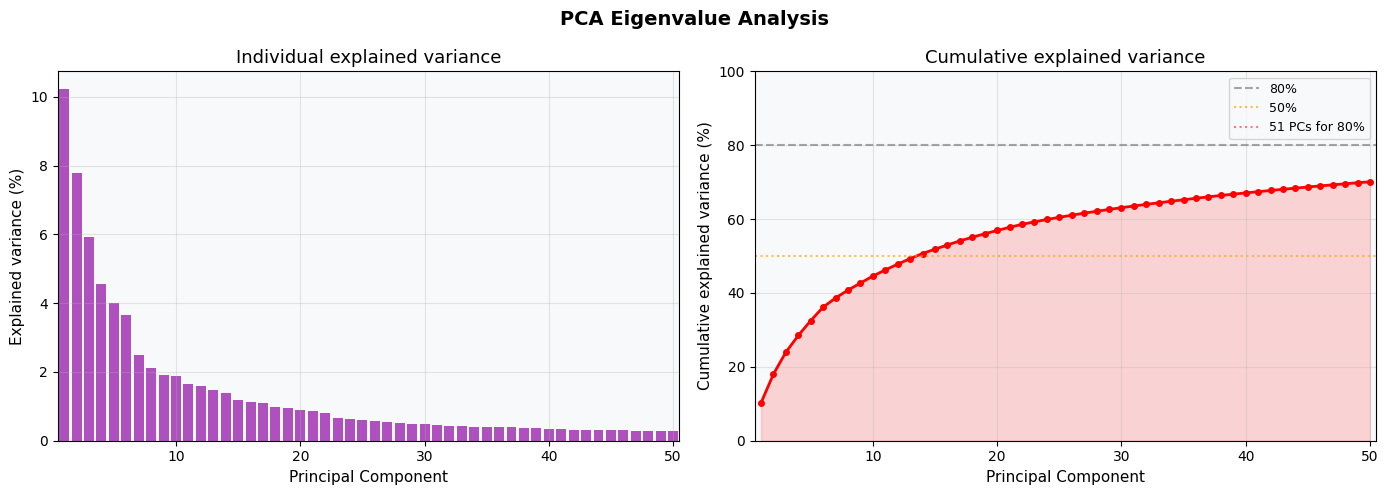

Need 51 PCs to reach 80% variance — the data is genuinely high-dimensional.


In [ ]:
# 2C · PCA scree and cumulative variance
n_pcs = min(50, X_train.shape[0] - 1)
pca   = PCA(n_components=n_pcs, random_state=42).fit(X_train)
evr   = pca.explained_variance_ratio_ * 100
cum   = np.cumsum(evr)
comps = np.arange(1, n_pcs + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("PCA Eigenvalue Analysis", fontsize=14, fontweight="bold")

axes[0].bar(comps, evr, color="#9C27B0", alpha=0.8)
axes[0].set(xlabel="Principal Component", ylabel="Explained variance (%)",
            title="Individual explained variance", xlim=(0.5, n_pcs + 0.5))

axes[1].plot(comps, cum, "r-o", markersize=4, linewidth=2)
axes[1].axhline(80, color="gray",   linestyle="--", alpha=0.7, label="80%")
axes[1].axhline(50, color="orange", linestyle=":",  alpha=0.7, label="50%")
n80 = int(np.searchsorted(cum, 80) + 1)
axes[1].axvline(n80, color="red", linestyle=":", alpha=0.5, label=f"{n80} PCs for 80%")
axes[1].fill_between(comps, cum, alpha=0.15, color="red")
axes[1].set(xlabel="Principal Component", ylabel="Cumulative explained variance (%)",
            title="Cumulative explained variance",
            xlim=(0.5, n_pcs + 0.5), ylim=(0, 100))
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(RES_DIR / "eda_pca_scree.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Need {n80} PCs to reach 80% variance — the data is genuinely high-dimensional.")

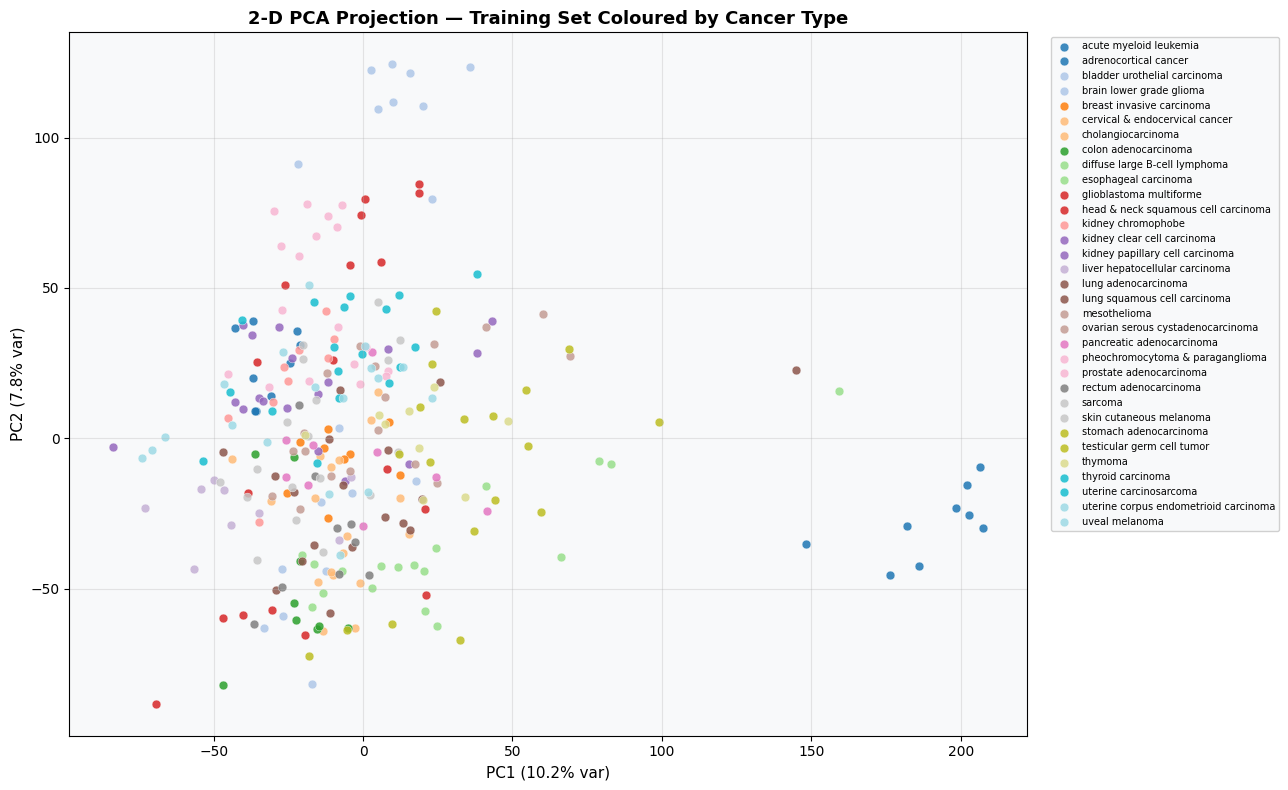

In [ ]:
# 2D · 2-D PCA scatter coloured by cancer type
X2 = PCA(n_components=2, random_state=42).fit_transform(X_train)
fig, ax = plt.subplots(figsize=(13, 8))
palette = plt.cm.tab20(np.linspace(0, 1, n_classes))
for i, cls in enumerate(le.classes_):
    m = y_train == i
    ax.scatter(X2[m, 0], X2[m, 1], color=palette[i], s=40, alpha=0.85,
               edgecolors="white", linewidths=0.3, label=cls)
ax.set_xlabel(f"PC1 ({evr[0]:.1f}% var)")
ax.set_ylabel(f"PC2 ({evr[1]:.1f}% var)")
ax.set_title("2-D PCA Projection — Training Set Coloured by Cancer Type", fontsize=13, fontweight="bold")
ax.legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left", ncol=1, framealpha=0.9)
plt.tight_layout()
plt.savefig(RES_DIR / "eda_pca2d.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 3 — Lasso Regularisation Path

Fit L1 logistic regression at 25 values of `C = 1/λ`. Watch sparsity decrease and validation accuracy rise as the penalty weakens, then plateau.

In [ ]:
# Lasso path — liblinear is 5-10x faster than saga for this problem size
N_LASSO_GENES = min(2000, n_features)
Xtr_l = X_train[:, :N_LASSO_GENES]
Xv_l  = X_val[:,   :N_LASSO_GENES]

C_values = np.logspace(-2, 2, 25)
n_nonzero, val_accs, coef_paths = [], [], []

print(f"{'C':>10}  {'non-zero genes':>16}  {'val acc':>10}")
print("-" * 42)
for C in C_values:
    clf = LogisticRegression(
        penalty="l1", solver="liblinear",   # ← key change, 5-10x faster
        C=C, max_iter=200, random_state=42  # one-vs-rest internally, fine for path
    )
    clf.fit(Xtr_l, y_train)
    nz  = int(np.any(clf.coef_ != 0, axis=0).sum())
    acc = accuracy_score(y_val, clf.predict(Xv_l))
    n_nonzero.append(nz)
    val_accs.append(acc)
    coef_paths.append(clf.coef_.mean(axis=0))
    print(f"{C:>10.4f}  {nz:>16,}  {acc:>10.4f}")

best_idx = int(np.argmax(val_accs))
best_C   = C_values[best_idx]
print(f"\nBest C = {best_C:.4f} → {n_nonzero[best_idx]:,} genes, val acc = {val_accs[best_idx]:.4f}")

         C    non-zero genes     val acc
------------------------------------------
    0.0100                 0      0.0303
    0.0147                 0      0.0303
    0.0215                 0      0.0303
    0.0316                16      0.2525
    0.0464                59      0.5354
    0.0681               117      0.6970
    0.1000               170      0.8182
    0.1468               252      0.8586
    0.2154               356      0.8889
    0.3162               453      0.8990
    0.4642               524      0.8889
    0.6813               583      0.8889
    1.0000               624      0.8889
    1.4678               668      0.8889
    2.1544               703      0.8889
    3.1623               736      0.8889
    4.6416               778      0.8889
    6.8129               805      0.8889
   10.0000               845      0.8889
   14.6780               881      0.8889
   21.5443               908      0.8990
   31.6228               961      0.8990
   46.4159    

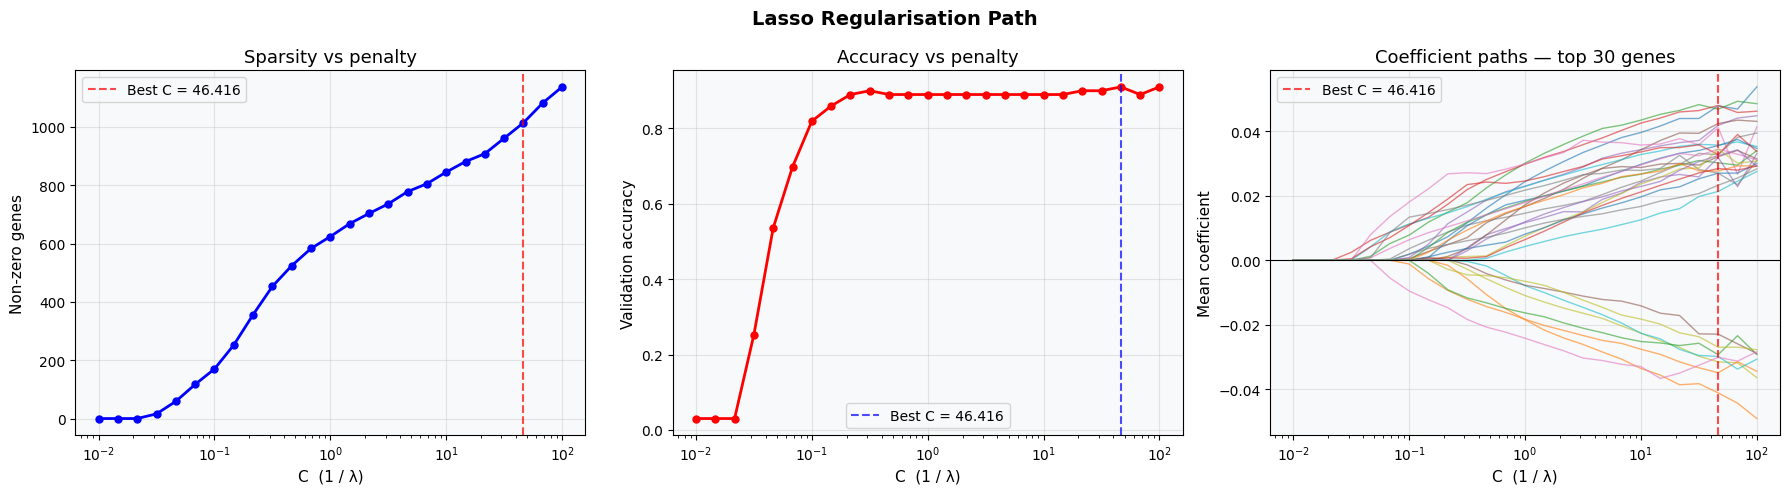

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Lasso Regularisation Path", fontsize=14, fontweight="bold")

axes[0].semilogx(C_values, n_nonzero, "b-o", markersize=5, lw=2)
axes[0].axvline(best_C, color="red", linestyle="--", alpha=0.7, label=f"Best C = {best_C:.3f}")
axes[0].set(xlabel="C  (1 / λ)", ylabel="Non-zero genes", title="Sparsity vs penalty"); axes[0].legend()

axes[1].semilogx(C_values, val_accs, "r-o", markersize=5, lw=2)
axes[1].axvline(best_C, color="blue", linestyle="--", alpha=0.7, label=f"Best C = {best_C:.3f}")
axes[1].set(xlabel="C  (1 / λ)", ylabel="Validation accuracy", title="Accuracy vs penalty"); axes[1].legend()

coef_mat = np.array(coef_paths)
top_g    = np.argsort(np.abs(coef_mat[-1]))[::-1][:30]
for j in top_g:
    axes[2].semilogx(C_values, coef_mat[:, j], alpha=0.6, lw=1)
axes[2].axhline(0, color="black", lw=0.8)
axes[2].axvline(best_C, color="red", linestyle="--", alpha=0.7, label=f"Best C = {best_C:.3f}")
axes[2].set(xlabel="C  (1 / λ)", ylabel="Mean coefficient",
            title="Coefficient paths — top 30 genes")
axes[2].legend()

plt.tight_layout()
plt.savefig(RES_DIR / "step3_lasso_path.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 4 Main Optimizer × Schedule × Regularizer Benchmark

A single-layer linear classifier (multinomial logistic regression) is fit under every combination of optimizer, schedule, regularizer, and seed. Architecture and loss are identical across all 144 runs while only the optimization differs.

| Factor       | Levels                                                                        |
|--------------|-------------------------------------------------------------------------------|
| Optimizer    | GD · SGD (b=1) · Mini-batch SGD · SGD+Momentum · Adam · L-BFGS                |
| LR schedule  | Constant · Cosine decay · Exponential decay · Warm restarts                   |
| Regularizer  | L1 (Lasso) · L2 (Ridge)                                                        |
| Seeds        | 42 · 123 · 2026                                                                |

In [ ]:
# Linear classifier (= multinomial logistic regression)
class LinearClassifier(nn.Module):
    def __init__(self, p, k):
        super().__init__()
        self.linear = nn.Linear(p, k)
    def forward(self, x):
        return self.linear(x)

def to_tensor(a, dtype=torch.float32):
    return torch.tensor(a, dtype=dtype, device=DEVICE)

X_tr_t, y_tr_t = to_tensor(X_train), to_tensor(y_train, torch.long)
X_v_t,  y_v_t  = to_tensor(X_val),   to_tensor(y_val,   torch.long)
X_te_t, y_te_t = to_tensor(X_test),  to_tensor(y_test,  torch.long)

BATCH_SIZE = 32
N_EPOCHS   = 100

train_ds   = TensorDataset(X_tr_t, y_tr_t)
dl_full    = DataLoader(train_ds, batch_size=len(X_tr_t), shuffle=False)   # GD, L-BFGS
dl_one     = DataLoader(train_ds, batch_size=1,           shuffle=True)    # SGD (true batch=1)
dl_mini    = DataLoader(train_ds, batch_size=BATCH_SIZE,  shuffle=True)    # mini-batch / Adam / Momentum

def get_loader(opt_name):
    if opt_name in ("GD", "L-BFGS"):
        return dl_full
    if opt_name == "SGD":
        return dl_one
    return dl_mini

print(f"Model    : LinearClassifier({n_features:,} → {n_classes})")
print(f"Epochs   : {N_EPOCHS}   |  Mini-batch size : {BATCH_SIZE}")
print(f"Train N  : {len(X_train)}   ·  Val N : {len(X_val)}   ·  Test N : {len(X_test)}")

Model    : LinearClassifier(20,000 → 33)
Epochs   : 100   |  Mini-batch size : 32
Train N  : 297   ·  Val N : 99   ·  Test N : 99


In [ ]:
def reg_loss(model, reg_type, lam=1e-4):
    w = model.linear.weight
    return lam * (w.abs().sum() if reg_type == "l1" else (w ** 2).sum())

def build_optimizer(name, model, lr):
    p = model.parameters()
    if name in ("GD", "SGD", "Mini-batch SGD"):
        return optim.SGD(p, lr=lr, momentum=0.0)
    if name == "SGD+Momentum":
        return optim.SGD(p, lr=lr, momentum=0.9)
    if name == "Adam":
        return optim.Adam(p, lr=lr)
    if name == "L-BFGS":
        return optim.LBFGS(p, lr=lr, max_iter=20)
    raise ValueError(name)

def build_scheduler(name, opt, n_epochs):
    if name == "Constant":          return None
    if name == "Cosine Decay":      return optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)
    if name == "Exponential Decay": return optim.lr_scheduler.ExponentialLR(opt, gamma=0.97)
    if name == "Warm Restarts":     return optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=25)
    raise ValueError(name)

In [ ]:
criterion = nn.CrossEntropyLoss()

def train_model(opt_name, sch_name, reg_type, seed, lr=0.01, n_epochs=N_EPOCHS):
    torch.manual_seed(seed); np.random.seed(seed)

    model     = LinearClassifier(n_features, n_classes).to(DEVICE)
    optimizer = build_optimizer(opt_name, model, lr)
    scheduler = build_scheduler(sch_name, optimizer, n_epochs)
    loader    = get_loader(opt_name)

    train_losses, val_accs, lr_history = [], [], []
    t0 = time.time()

    for epoch in range(n_epochs):
        model.train()
        ep_loss, n_b = 0.0, 0

        if opt_name == "L-BFGS":
            def closure():
                optimizer.zero_grad()
                loss = criterion(model(X_tr_t), y_tr_t) + reg_loss(model, reg_type)
                loss.backward()
                return loss
            loss = optimizer.step(closure)
            ep_loss, n_b = loss.item(), 1
        else:
            for Xb, yb in loader:
                optimizer.zero_grad()
                loss = criterion(model(Xb), yb) + reg_loss(model, reg_type)
                loss.backward()
                optimizer.step()
                ep_loss += loss.item()
                n_b += 1

        train_losses.append(ep_loss / n_b)
        lr_history.append(optimizer.param_groups[0]["lr"])

        model.eval()
        with torch.no_grad():
            val_pred = model(X_v_t).argmax(1).cpu().numpy()
        val_accs.append(accuracy_score(y_val, val_pred))

        if scheduler is not None:
            scheduler.step()

    elapsed = time.time() - t0

    model.eval()
    with torch.no_grad():
        test_pred = model(X_te_t).argmax(1).cpu().numpy()

    return {
        "train_losses": train_losses,
        "val_accs":     val_accs,
        "lr_history":   lr_history,
        "val_acc":      val_accs[-1],
        "test_acc":     accuracy_score(y_test, test_pred),
        "test_f1":      f1_score(y_test, test_pred, average="macro", zero_division=0),
        "train_time_s": elapsed,
        "final_loss":   train_losses[-1],
        "model":        model,
    }

In [ ]:
# Run the full 6 × 4 × 2 × 3 = 144 grid
OPTIMIZERS   = ["GD", "SGD", "Mini-batch SGD", "SGD+Momentum", "Adam", "L-BFGS"]
LR_SCHEDULES = ["Constant", "Cosine Decay", "Exponential Decay", "Warm Restarts"]
REGULARIZERS = ["l1", "l2"]
SEEDS        = [42, 123, 2026]

LR_MAP = {
    "GD":             0.01,
    "SGD":            0.01,
    "Mini-batch SGD": 0.01,
    "SGD+Momentum":   0.005,
    "Adam":           0.001,
    "L-BFGS":         0.1,
}

results    = []
all_curves = defaultdict(list)
total      = len(OPTIMIZERS) * len(LR_SCHEDULES) * len(REGULARIZERS) * len(SEEDS)
i = 0

for opt in OPTIMIZERS:
    for sch in LR_SCHEDULES:
        for reg in REGULARIZERS:
            for seed in SEEDS:
                i += 1
                res = train_model(opt, sch, reg, seed, lr=LR_MAP[opt])
                results.append({
                    "optimizer":    opt,
                    "lr_schedule":  sch,
                    "regularizer":  reg,
                    "seed":         seed,
                    "final_loss":   res["final_loss"],
                    "val_acc":      res["val_acc"],
                    "test_acc":     res["test_acc"],
                    "test_f1":      res["test_f1"],
                    "train_time_s": res["train_time_s"],
                })
                all_curves[(opt, sch, reg)].append(res["train_losses"])
                print(f"[{i:3d}/{total}] {opt:15s} | {sch:18s} | {reg} | seed={seed:4d} "
                      f"| val={res['val_acc']:.3f} | test={res['test_acc']:.3f} "
                      f"| F1={res['test_f1']:.3f} | t={res['train_time_s']:.1f}s")

df = pd.DataFrame(results)
df.to_csv(RES_DIR / "step4_results.csv", index=False)
print(f"\nAll {total} runs complete. Mean by optimizer:\n")
print(df.groupby("optimizer")[["val_acc","test_acc","test_f1","train_time_s"]].mean().round(3))

[  1/144] GD              | Constant           | l1 | seed=  42 | val=0.919 | test=0.899 | F1=0.892 | t=0.8s
[  2/144] GD              | Constant           | l1 | seed= 123 | val=0.909 | test=0.889 | F1=0.881 | t=0.6s
[  3/144] GD              | Constant           | l1 | seed=2026 | val=0.939 | test=0.889 | F1=0.879 | t=0.4s
[  4/144] GD              | Constant           | l2 | seed=  42 | val=0.919 | test=0.899 | F1=0.892 | t=0.4s
[  5/144] GD              | Constant           | l2 | seed= 123 | val=0.909 | test=0.889 | F1=0.881 | t=0.4s
[  6/144] GD              | Constant           | l2 | seed=2026 | val=0.939 | test=0.889 | F1=0.879 | t=0.4s
[  7/144] GD              | Cosine Decay       | l1 | seed=  42 | val=0.919 | test=0.899 | F1=0.892 | t=0.4s
[  8/144] GD              | Cosine Decay       | l1 | seed= 123 | val=0.909 | test=0.879 | F1=0.871 | t=0.4s
[  9/144] GD              | Cosine Decay       | l1 | seed=2026 | val=0.929 | test=0.879 | F1=0.869 | t=0.4s
[ 10/144] GD       

### 4A Convergence curves

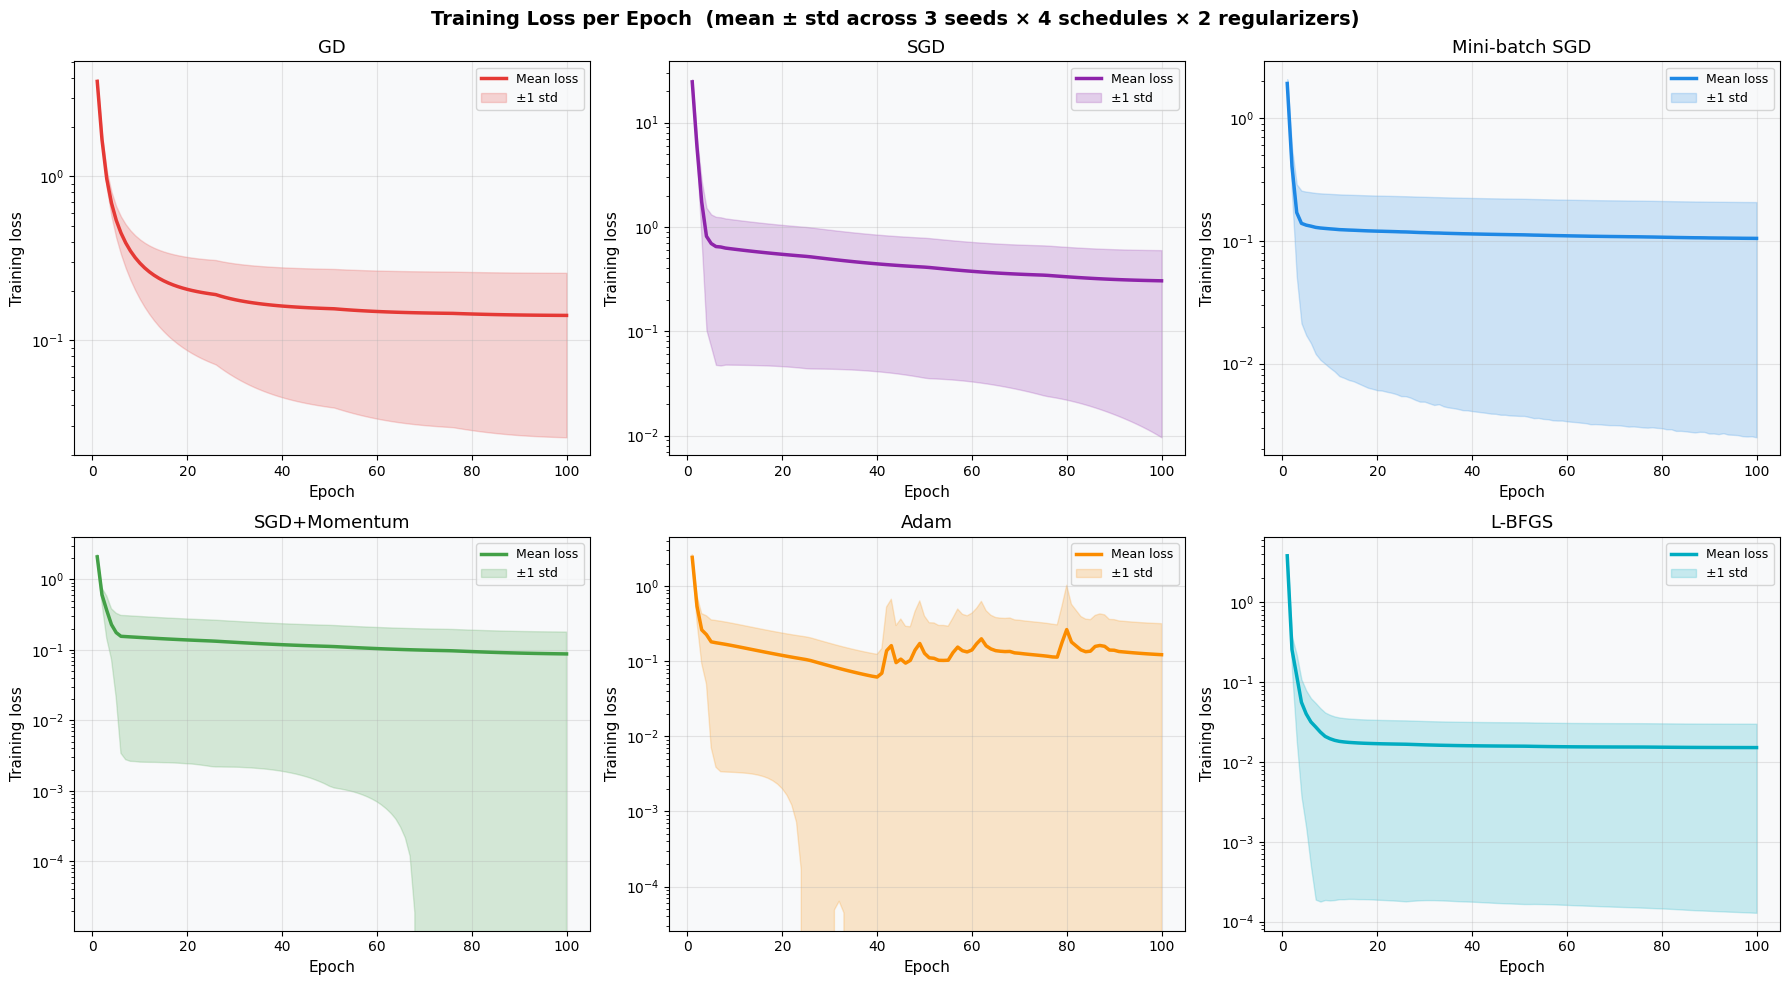

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Training Loss per Epoch  (mean ± std across 3 seeds × 4 schedules × 2 regularizers)",
             fontsize=14, fontweight="bold")
axes  = axes.flatten()
colors = ["#E53935", "#8E24AA", "#1E88E5", "#43A047", "#FB8C00", "#00ACC1"]

for ax_i, opt in enumerate(OPTIMIZERS):
    ax = axes[ax_i]
    runs = []
    for sch in LR_SCHEDULES:
        for reg in REGULARIZERS:
            runs.extend(all_curves[(opt, sch, reg)])
    arr  = np.array(runs)
    mean = arr.mean(axis=0)
    std  = arr.std(axis=0)
    ep   = np.arange(1, len(mean) + 1)
    ax.plot(ep, mean, color=colors[ax_i], linewidth=2.5, label="Mean loss")
    ax.fill_between(ep, mean - std, mean + std, alpha=0.2, color=colors[ax_i], label="±1 std")
    ax.set(title=opt, xlabel="Epoch", ylabel="Training loss")
    ax.set_yscale("log")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(RES_DIR / "step4_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

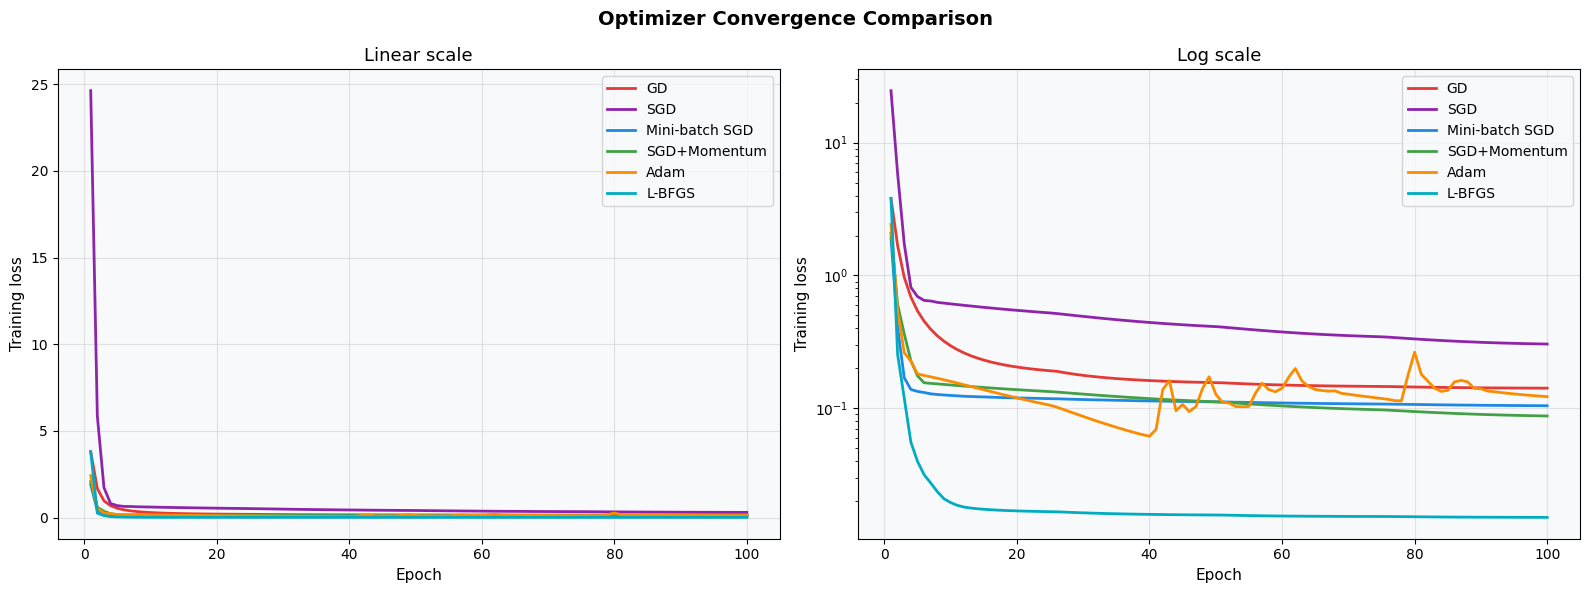

In [ ]:
# All optimizers on a single panel :-linear and log
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Optimizer Convergence Comparison", fontsize=14, fontweight="bold")

for ci, opt in enumerate(OPTIMIZERS):
    runs = []
    for sch in LR_SCHEDULES:
        for reg in REGULARIZERS:
            runs.extend(all_curves[(opt, sch, reg)])
    mean = np.array(runs).mean(axis=0)
    ep   = np.arange(1, len(mean) + 1)
    ax1.plot(ep, mean, color=colors[ci], linewidth=2, label=opt)
    ax2.semilogy(ep, mean, color=colors[ci], linewidth=2, label=opt)

for ax, t in zip([ax1, ax2], ["Linear scale", "Log scale"]):
    ax.set(xlabel="Epoch", ylabel="Training loss", title=t)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(RES_DIR / "step4_convergence_combined.png", dpi=150, bbox_inches="tight")
plt.show()

### 4B  Benchmark summary

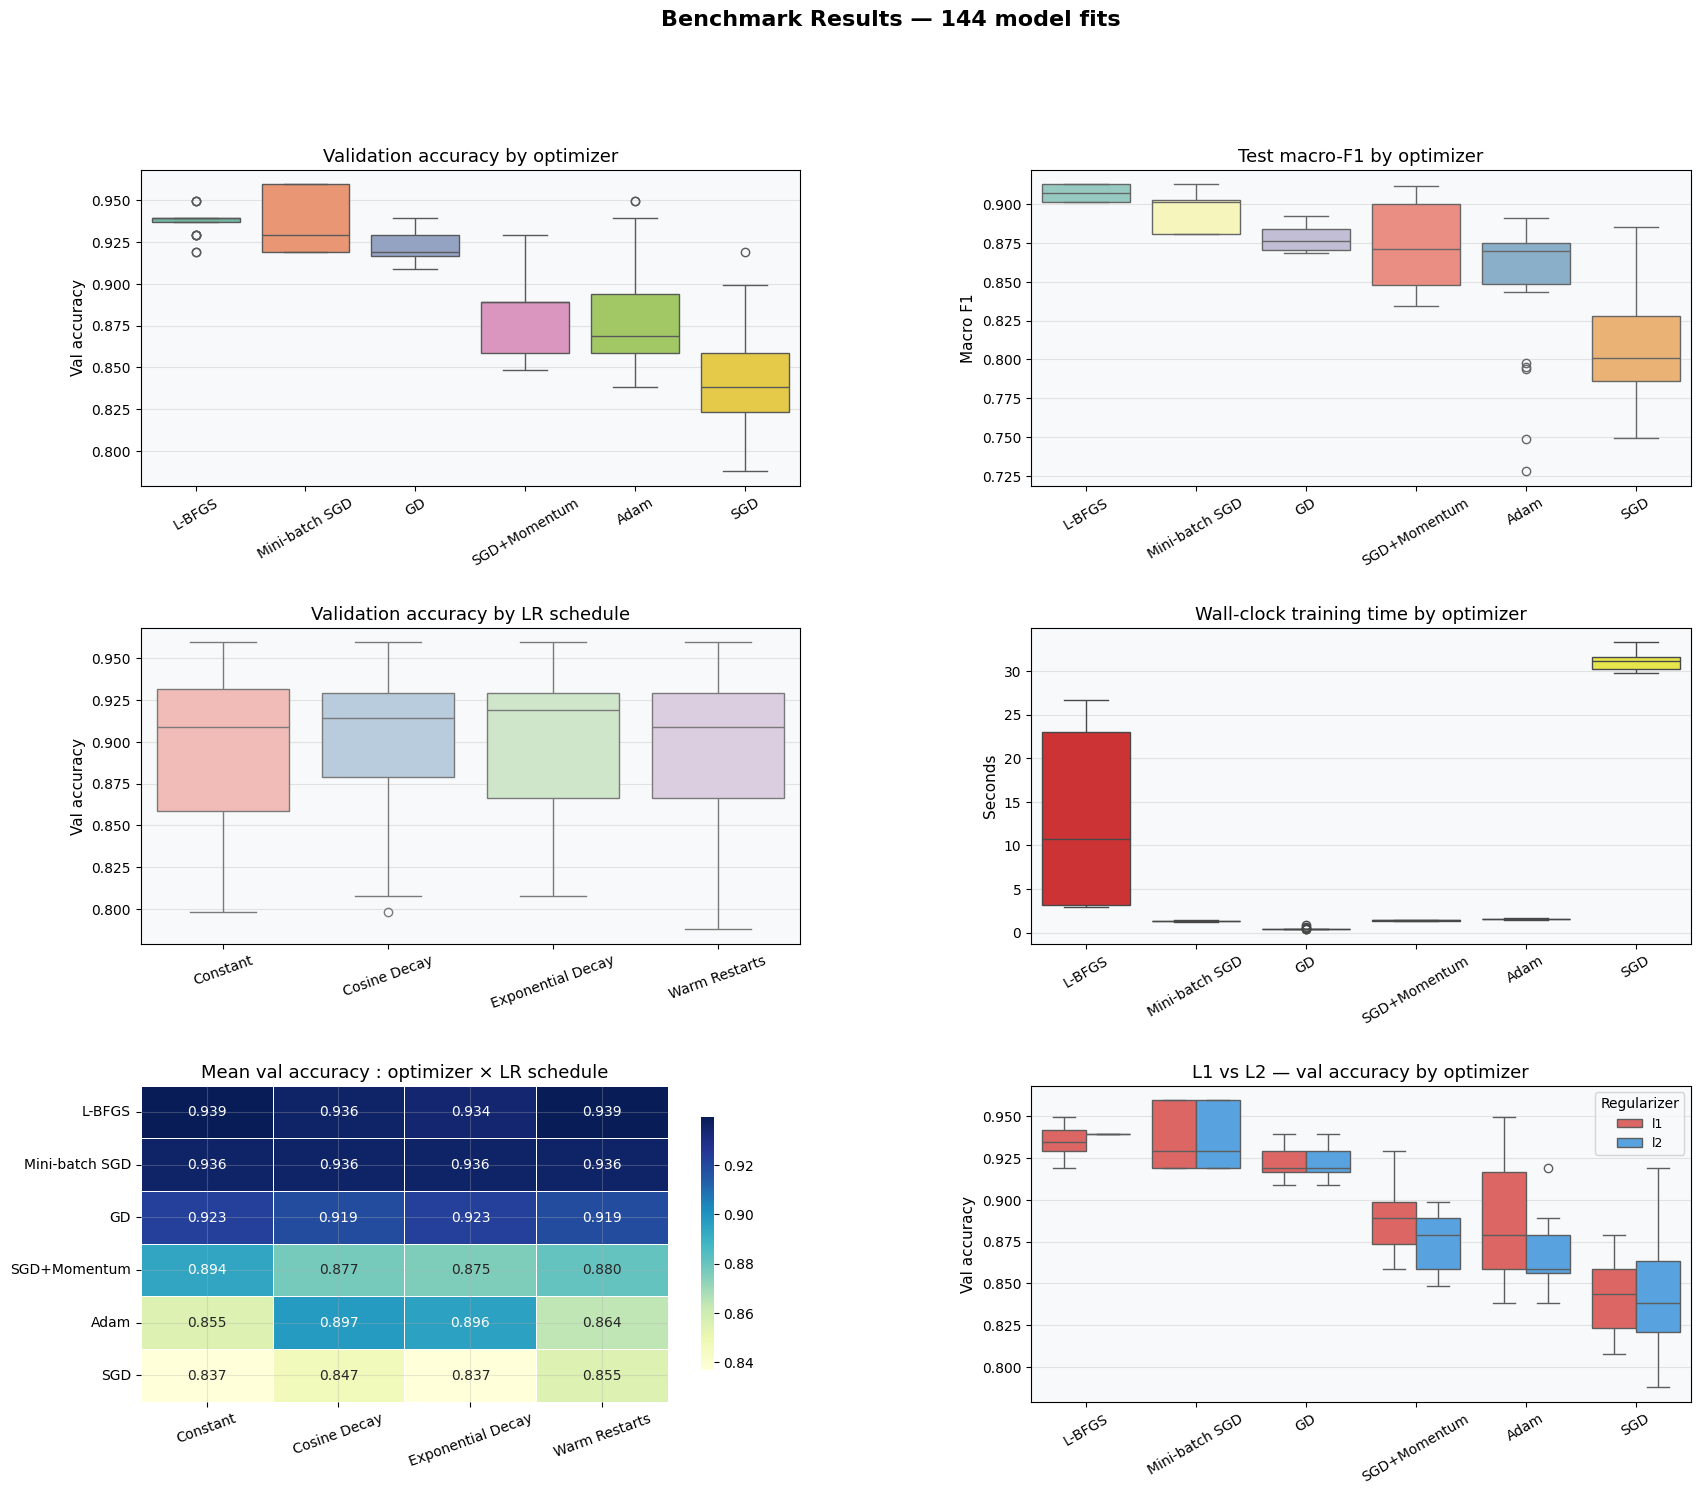

In [ ]:
opt_order = (df.groupby("optimizer")["val_acc"]
               .mean().sort_values(ascending=False).index.tolist())

fig = plt.figure(figsize=(20, 16))
fig.suptitle("Benchmark Results — 144 model fits", fontsize=16, fontweight="bold")
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

ax = fig.add_subplot(gs[0, 0])
sns.boxplot(data=df, x="optimizer", y="val_acc", order=opt_order, palette="Set2", ax=ax)
ax.set(title="Validation accuracy by optimizer", xlabel="", ylabel="Val accuracy")
ax.tick_params(axis="x", rotation=30)

ax = fig.add_subplot(gs[0, 1])
sns.boxplot(data=df, x="optimizer", y="test_f1", order=opt_order, palette="Set3", ax=ax)
ax.set(title="Test macro-F1 by optimizer", xlabel="", ylabel="Macro F1")
ax.tick_params(axis="x", rotation=30)

ax = fig.add_subplot(gs[1, 0])
sns.boxplot(data=df, x="lr_schedule", y="val_acc", palette="Pastel1", ax=ax)
ax.set(title="Validation accuracy by LR schedule", xlabel="", ylabel="Val accuracy")
ax.tick_params(axis="x", rotation=20)

ax = fig.add_subplot(gs[1, 1])
sns.boxplot(data=df, x="optimizer", y="train_time_s", order=opt_order, palette="Set1", ax=ax)
ax.set(title="Wall-clock training time by optimizer", xlabel="", ylabel="Seconds")
ax.tick_params(axis="x", rotation=30)

ax = fig.add_subplot(gs[2, 0])
pivot = df.groupby(["optimizer", "lr_schedule"])["val_acc"].mean().unstack().loc[opt_order]
sns.heatmap(pivot, ax=ax, annot=True, fmt=".3f", cmap="YlGnBu",
            linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set(title="Mean val accuracy : optimizer × LR schedule", xlabel="", ylabel="")
ax.tick_params(axis="x", rotation=20)

ax = fig.add_subplot(gs[2, 1])
sns.boxplot(data=df, x="optimizer", y="val_acc", hue="regularizer",
            order=opt_order, palette={"l1": "#EF5350", "l2": "#42A5F5"}, ax=ax)
ax.set(title="L1 vs L2 — val accuracy by optimizer", xlabel="", ylabel="Val accuracy")
ax.legend(title="Regularizer", fontsize=9)
ax.tick_params(axis="x", rotation=30)

plt.savefig(RES_DIR / "step4_summary.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Tabular summary, mean ± std across the 3 seeds
summary = (df.groupby(["optimizer", "lr_schedule", "regularizer"])
             [["val_acc", "test_acc", "test_f1", "train_time_s"]]
             .agg(["mean", "std"])
             .round(4))
print("Full results (mean ± std across seeds):\n")
print(summary.to_string())

Full results (mean ± std across seeds):

                                             val_acc         test_acc         test_f1         train_time_s        
                                                mean     std     mean     std    mean     std         mean     std
optimizer      lr_schedule       regularizer                                                                      
Adam           Constant          l1           0.8519  0.0117   0.7912  0.0382  0.7721  0.0383       1.5535  0.0842
                                 l2           0.8586  0.0202   0.8788  0.0000  0.8707  0.0036       1.5003  0.0101
               Cosine Decay      l1           0.9360  0.0233   0.8956  0.0058  0.8878  0.0049       1.5490  0.0181
                                 l2           0.8586  0.0202   0.8788  0.0000  0.8707  0.0036       1.5454  0.0325
               Exponential Decay l1           0.9091  0.0303   0.8754  0.0058  0.8704  0.0055       1.5536  0.0058
                                 l2    

Best model: Mini-batch SGD | Constant | l1 | seed=42
Test acc = 0.9192  Macro-F1 = 0.9130


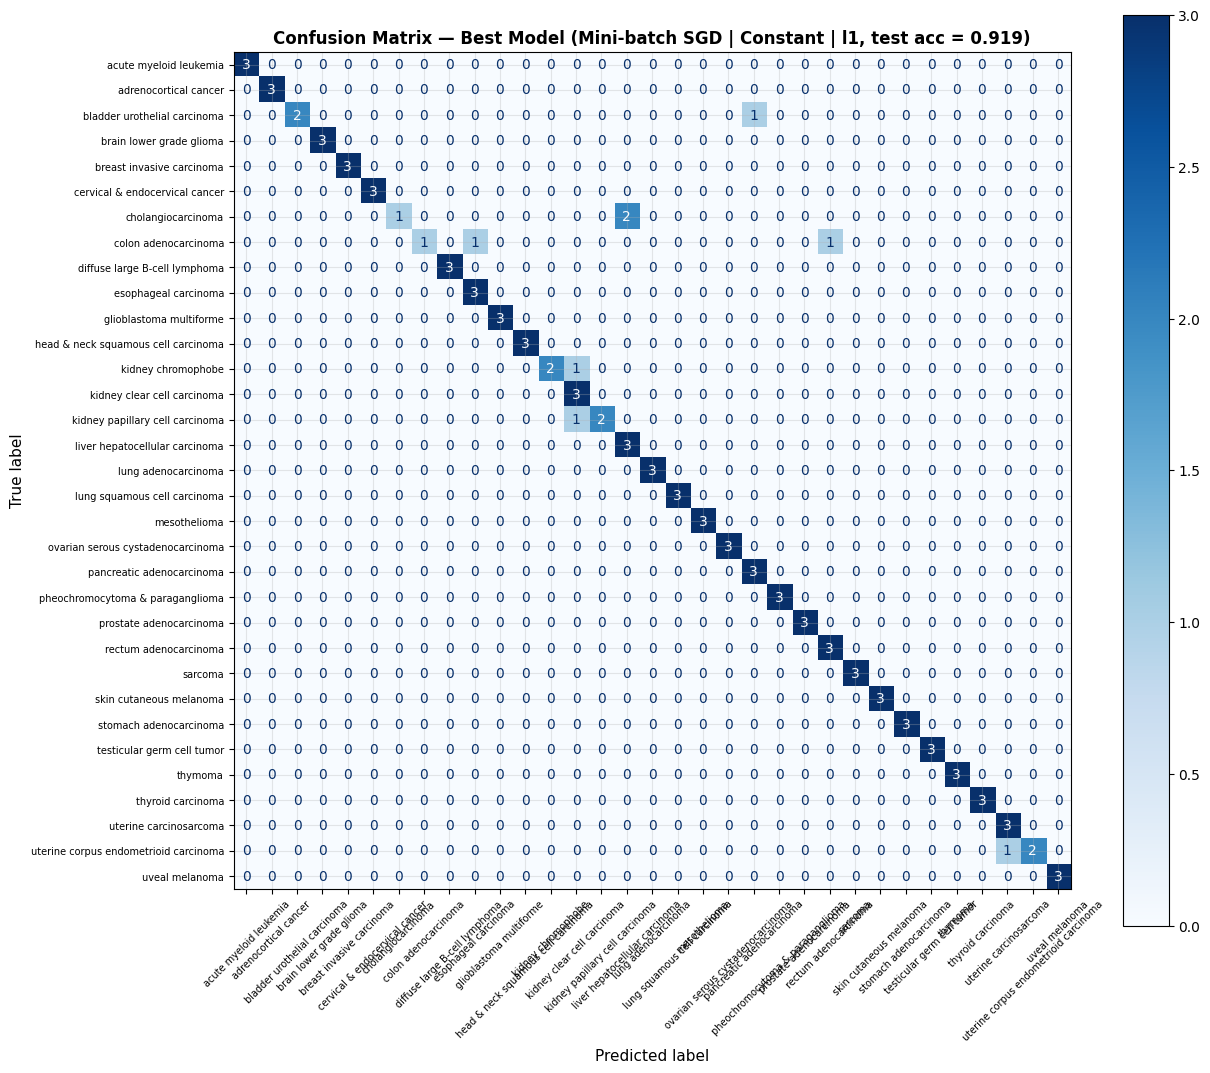

In [ ]:
# Confusion matrix for the single best run
best = df.loc[df["test_acc"].idxmax()]
print(f"Best model: {best['optimizer']} | {best['lr_schedule']} | "
      f"{best['regularizer']} | seed={int(best['seed'])}")
print(f"Test acc = {best['test_acc']:.4f}  Macro-F1 = {best['test_f1']:.4f}")

best_model = train_model(best["optimizer"], best["lr_schedule"],
                         best["regularizer"], int(best["seed"]),
                         lr=LR_MAP[best["optimizer"]])["model"]
best_model.eval()
with torch.no_grad():
    preds = best_model(X_te_t).argmax(1).cpu().numpy()

cm = confusion_matrix(y_test, preds)
fig, ax = plt.subplots(figsize=(13, 11))
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
    ax=ax, colorbar=True, xticks_rotation=45, cmap="Blues")
ax.set_title(f"Confusion Matrix — Best Model "
             f"({best['optimizer']} | {best['lr_schedule']} | {best['regularizer']}, "
             f"test acc = {best['test_acc']:.3f})", fontsize=12, fontweight="bold")
ax.tick_params(axis="both", labelsize=7)
plt.tight_layout()
plt.savefig(RES_DIR / "step4_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 5 Learning-Rate Sensitivity

A logarithmic sweep of SGD across six fixed learning rates exposes the three regimes are too small, optimal, diverging.

In [ ]:
lr_values = [0.0001, 0.001, 0.01, 0.05, 0.2, 0.5]
lr_colors = ["#FF6F00", "#FDD835", "#43A047", "#43A047", "#E53935", "#B71C1C"]
lr_labels = ["Too small", "Too small", "Optimal", "Optimal", "Diverging", "Diverging"]

lr_results = {}
for lr in lr_values:
    res = train_model("SGD", "Constant", "l2", seed=42, lr=lr)
    lr_results[lr] = res
    print(f"LR={lr:.4f}  final_loss={res['final_loss']:.4f}  "
          f"val_acc={res['val_acc']:.4f}  time={res['train_time_s']:.1f}s")

LR=0.0001  final_loss=0.0051  val_acc=0.9192  time=31.4s
LR=0.0010  final_loss=0.0015  val_acc=0.9091  time=31.5s
LR=0.0100  final_loss=0.0429  val_acc=0.8788  time=31.6s
LR=0.0500  final_loss=0.7224  val_acc=0.8384  time=33.2s
LR=0.2000  final_loss=1.9570  val_acc=0.8687  time=32.0s
LR=0.5000  final_loss=0.4105  val_acc=0.8081  time=32.0s


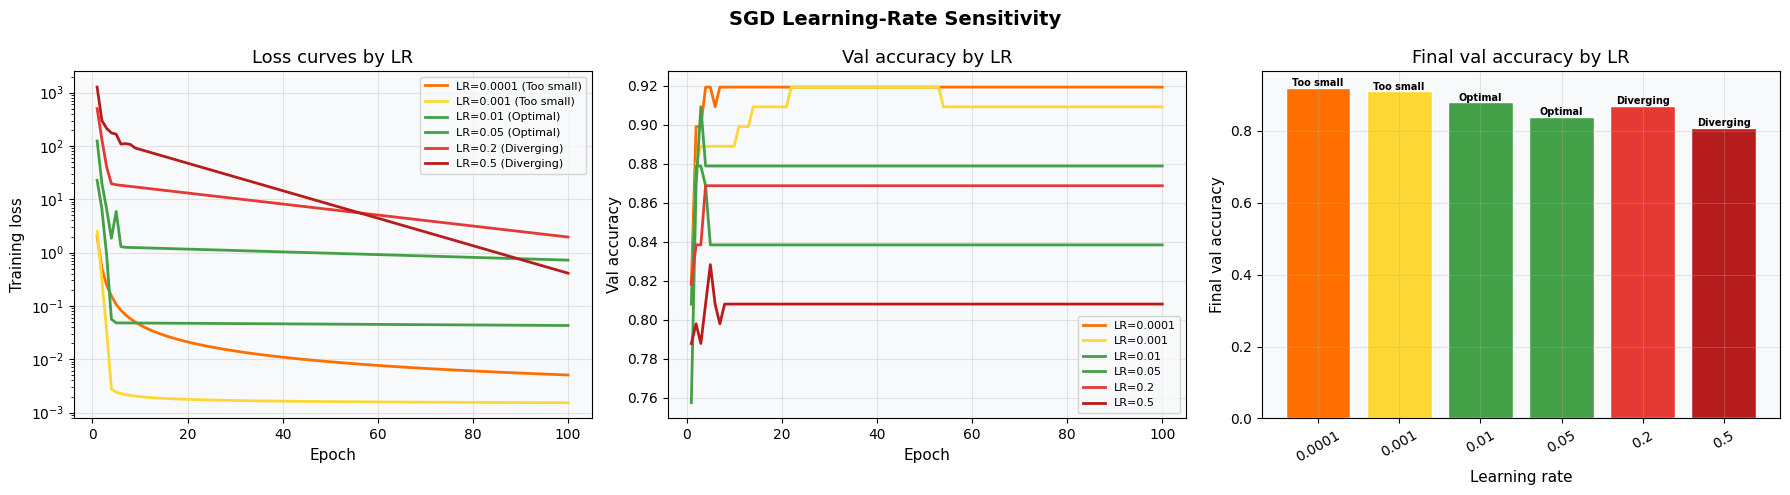

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("SGD Learning-Rate Sensitivity", fontsize=14, fontweight="bold")

for i, lr in enumerate(lr_values):
    ep = np.arange(1, len(lr_results[lr]["train_losses"]) + 1)
    axes[0].plot(ep, lr_results[lr]["train_losses"], color=lr_colors[i],
                 linewidth=2, label=f"LR={lr} ({lr_labels[i]})")
axes[0].set(xlabel="Epoch", ylabel="Training loss", title="Loss curves by LR")
axes[0].set_yscale("log"); axes[0].legend(fontsize=8)

for i, lr in enumerate(lr_values):
    ep = np.arange(1, len(lr_results[lr]["val_accs"]) + 1)
    axes[1].plot(ep, lr_results[lr]["val_accs"], color=lr_colors[i],
                 linewidth=2, label=f"LR={lr}")
axes[1].set(xlabel="Epoch", ylabel="Val accuracy", title="Val accuracy by LR")
axes[1].legend(fontsize=8)

final_accs = [lr_results[lr]["val_acc"] for lr in lr_values]
bars = axes[2].bar([str(lr) for lr in lr_values], final_accs,
                   color=lr_colors, edgecolor="white")
axes[2].set(xlabel="Learning rate", ylabel="Final val accuracy",
            title="Final val accuracy by LR")
axes[2].tick_params(axis="x", rotation=30)
for bar, lab, acc in zip(bars, lr_labels, final_accs):
    axes[2].text(bar.get_x() + bar.get_width() / 2, acc + 0.005,
                 lab, ha="center", fontsize=7, fontweight="bold")

plt.tight_layout()
plt.savefig(RES_DIR / "step5_lr_study.png", dpi=150, bbox_inches="tight")
plt.show()

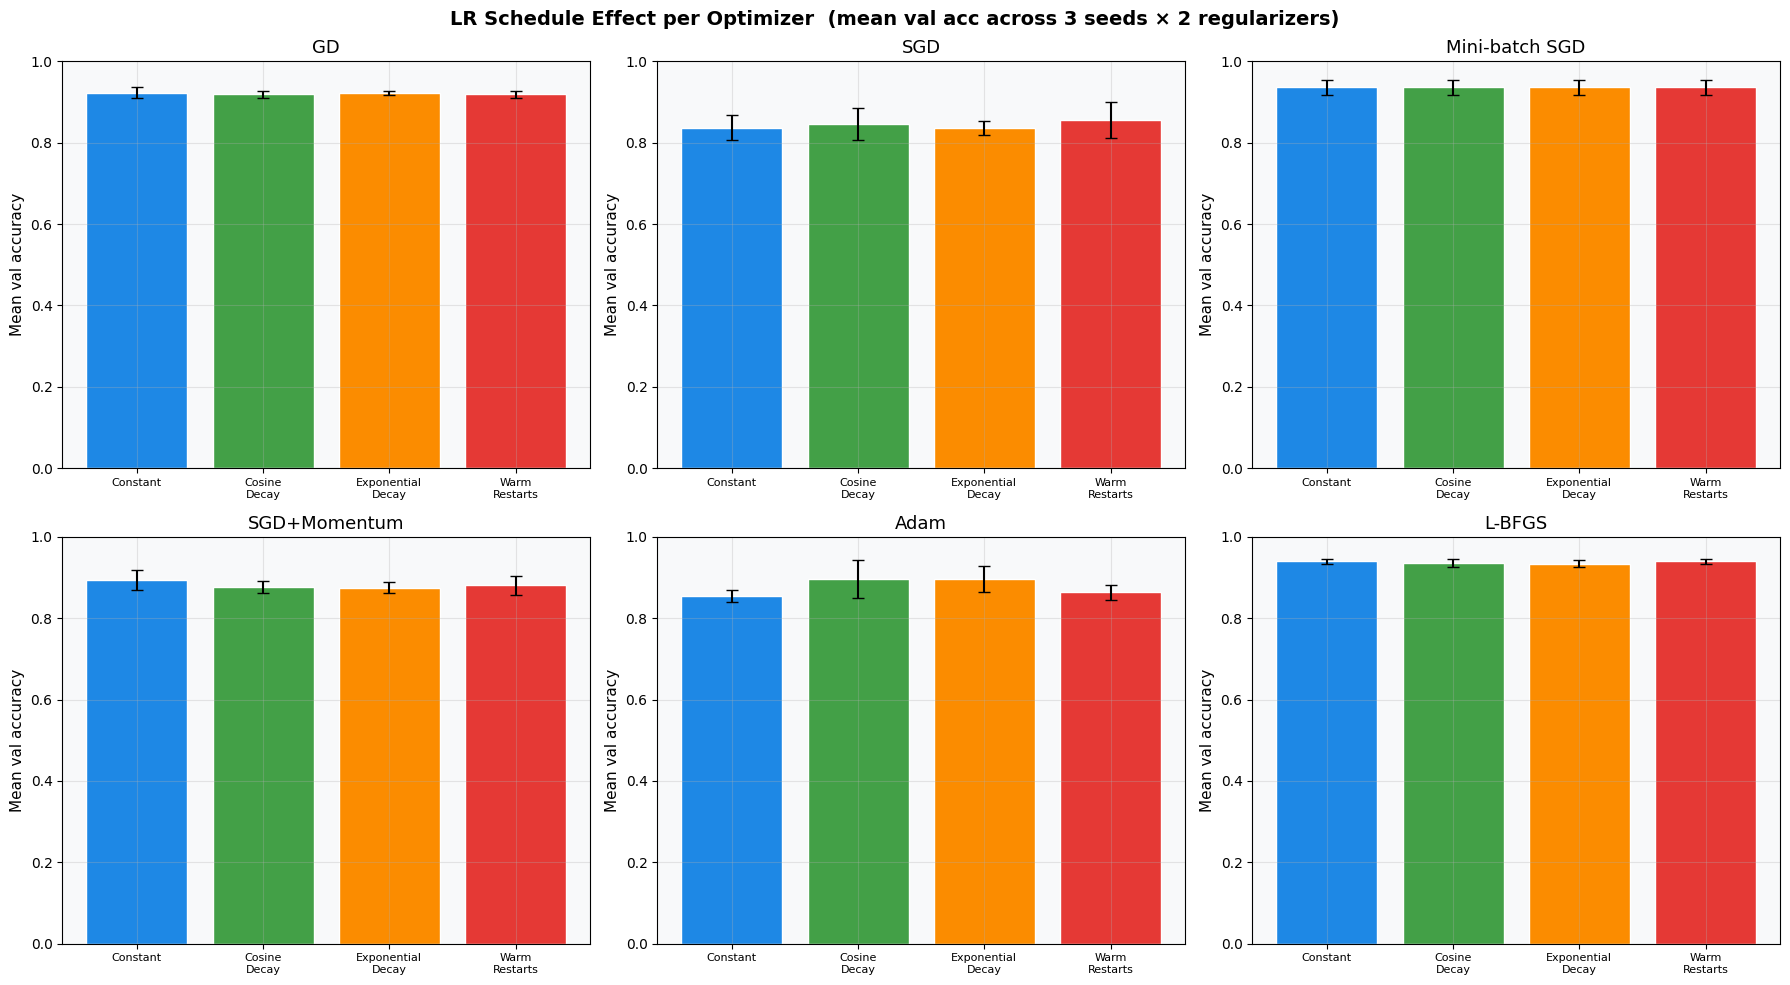

In [ ]:
# Schedule effect per optimizer
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("LR Schedule Effect per Optimizer  (mean val acc across 3 seeds × 2 regularizers)",
             fontsize=14, fontweight="bold")
axes = axes.flatten()
sched_colors = {"Constant": "#1E88E5", "Cosine Decay": "#43A047",
                "Exponential Decay": "#FB8C00", "Warm Restarts": "#E53935"}

for ax_i, opt in enumerate(OPTIMIZERS):
    ax = axes[ax_i]
    sub = df[df["optimizer"] == opt]
    means = sub.groupby("lr_schedule")["val_acc"].mean()
    stds  = sub.groupby("lr_schedule")["val_acc"].std()
    x = np.arange(len(LR_SCHEDULES))
    ax.bar(x,
           [means.get(s, 0) for s in LR_SCHEDULES],
           yerr=[stds.get(s, 0) for s in LR_SCHEDULES],
           color=[sched_colors[s] for s in LR_SCHEDULES],
           capsize=4, edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels([s.replace(" ", "\n") for s in LR_SCHEDULES], fontsize=8)
    ax.set(title=opt, ylabel="Mean val accuracy", ylim=(0, 1))

plt.tight_layout()
plt.savefig(RES_DIR / "step5_schedule_per_optimizer.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 6  Linear-Programming Gene-Selection Extension

Clinical genomic panels measure tens of genes, not tens of thousands. We pick the panel by solving:

$$\max_x \sum_j F_j x_j \quad \text{s.t.} \sum_j x_j \leq k, \; 0 \leq x_j \leq 1$$

where $F_j$ is the per-gene Fisher F-statistic. We compare LP-selected vs Lasso-selected panels at matched cardinality.

In [ ]:
# Per-gene Fisher F-statistic
print("Computing per-gene Fisher F-statistics …")
f_scores = np.zeros(n_features)
for j in range(n_features):
    groups = [X_train[y_train == c, j] for c in np.unique(y_train)]
    groups = [g for g in groups if len(g) > 1]
    if len(groups) > 1:
        try:
            F, _ = f_oneway(*groups)
            f_scores[j] = F if np.isfinite(F) else 0.0
        except Exception:
            f_scores[j] = 0.0

print(f"F-scores computed for {n_features:,} genes")
print(f"Max F        : {f_scores.max():.2f}")
print(f"Mean F       : {f_scores.mean():.2f}")
print(f"Genes F > 10 : {(f_scores > 10).sum():,}")

Computing per-gene Fisher F-statistics …
F-scores computed for 20,000 genes
Max F        : 107.16
Mean F       : 8.87
Genes F > 10 : 5,893


In [ ]:
# Solve LP at several budgets, compare with Lasso top-k
k_values   = [10, 25, 50, 100, 200]
lp_results, lasso_results = {}, {}

lasso_best = LogisticRegression(
    penalty="l1", solver="liblinear",
    C=best_C, max_iter=500,
    random_state=42
)
lasso_best.fit(X_train, y_train)
lasso_mask_full = np.any(lasso_best.coef_ != 0, axis=0)
lasso_rank      = np.argsort(np.abs(lasso_best.coef_).mean(axis=0))[::-1]

def eval_subset(idx):
    clf = LogisticRegression(solver="lbfgs", max_iter=500, random_state=42, n_jobs=-1)
    clf.fit(X_train[:, idx], y_train)
    val  = accuracy_score(y_val,  clf.predict(X_val[:,  idx]))
    test = accuracy_score(y_test, clf.predict(X_test[:, idx]))
    f1   = f1_score(y_test, clf.predict(X_test[:, idx]),
                    average="macro", zero_division=0)
    return {"val_acc": val, "test_acc": test, "test_f1": f1, "n_genes": len(idx)}

for k in k_values:
    res = linprog(-f_scores,
                  A_ub=np.ones((1, n_features)), b_ub=[k],
                  bounds=[(0, 1)] * n_features, method="highs")
    lp_idx    = (np.argsort(res.x)[::-1][:k] if res.success
                 else np.argsort(f_scores)[::-1][:k])
    lasso_idx = lasso_rank[:k]

    lp_e    = eval_subset(lp_idx)
    lasso_e = eval_subset(lasso_idx)
    overlap = len(set(lp_idx) & set(lasso_idx))

    lp_results[k]    = {**lp_e,    "overlap": overlap}
    lasso_results[k] = {**lasso_e, "overlap": overlap}

    print(f"k={k:4d}  LP: val={lp_e['val_acc']:.3f} test={lp_e['test_acc']:.3f}  | "
          f"Lasso: val={lasso_e['val_acc']:.3f} test={lasso_e['test_acc']:.3f}  | "
          f"overlap {overlap}/{k}")

full_val  = accuracy_score(y_val,  lasso_best.predict(X_val))
full_test = accuracy_score(y_test, lasso_best.predict(X_test))
full_f1   = f1_score(y_test, lasso_best.predict(X_test), average="macro", zero_division=0)
print(f"\nFull Lasso ({lasso_mask_full.sum()} genes): val={full_val:.3f} test={full_test:.3f} F1={full_f1:.3f}")

k=  10  LP: val=0.333 test=0.354  | Lasso: val=0.374 test=0.293  | overlap 0/10
k=  25  LP: val=0.677 test=0.596  | Lasso: val=0.556 test=0.636  | overlap 0/25
k=  50  LP: val=0.818 test=0.717  | Lasso: val=0.768 test=0.818  | overlap 0/50
k= 100  LP: val=0.859 test=0.798  | Lasso: val=0.859 test=0.859  | overlap 4/100
k= 200  LP: val=0.859 test=0.848  | Lasso: val=0.929 test=0.929  | overlap 8/200

Full Lasso (2820 genes): val=0.939 test=0.919 F1=0.915


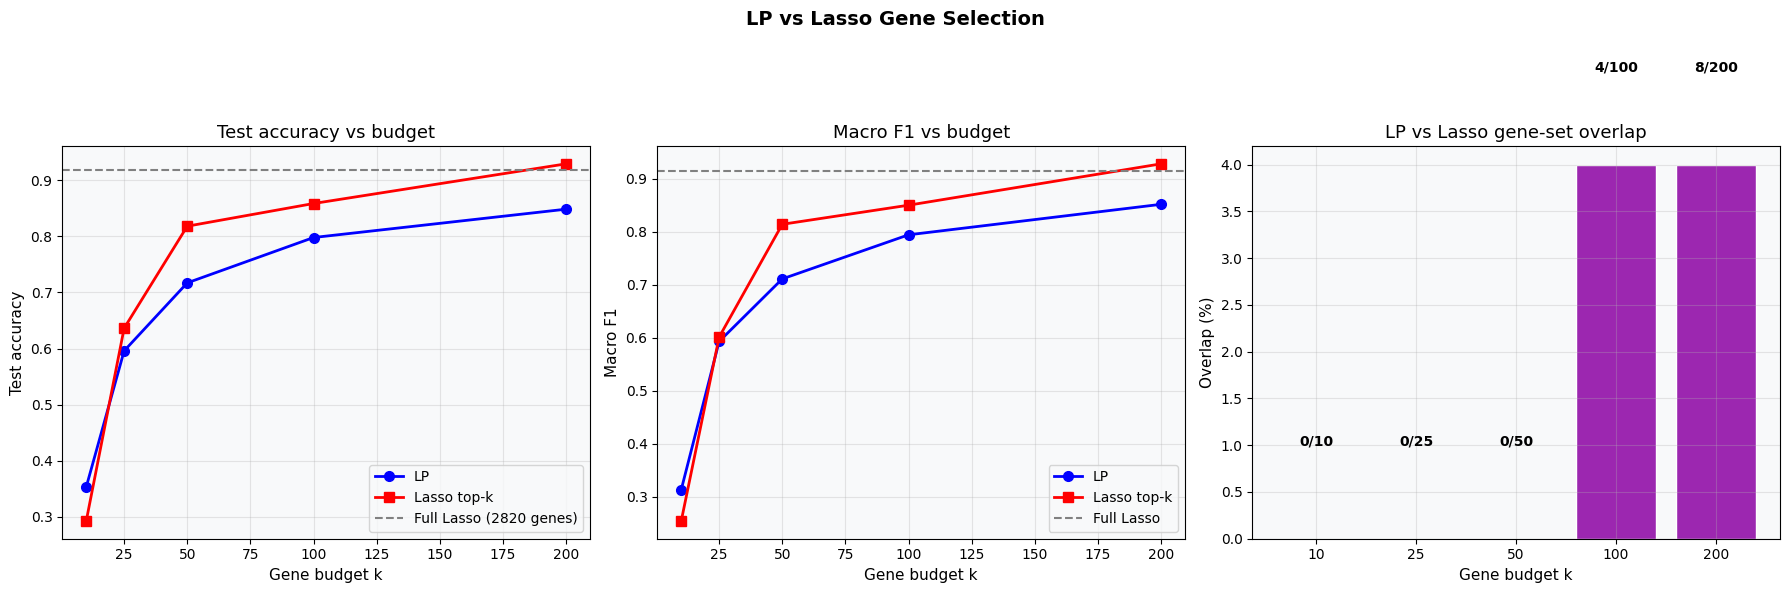

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("LP vs Lasso Gene Selection", fontsize=14, fontweight="bold")

lp_test    = [lp_results[k]["test_acc"]    for k in k_values]
lasso_test = [lasso_results[k]["test_acc"] for k in k_values]
axes[0].plot(k_values, lp_test,    "b-o", lw=2, ms=7, label="LP")
axes[0].plot(k_values, lasso_test, "r-s", lw=2, ms=7, label="Lasso top-k")
axes[0].axhline(full_test, color="gray", linestyle="--", lw=1.5,
                label=f"Full Lasso ({lasso_mask_full.sum()} genes)")
axes[0].set(xlabel="Gene budget k", ylabel="Test accuracy",
            title="Test accuracy vs budget"); axes[0].legend()

lp_f1    = [lp_results[k]["test_f1"]    for k in k_values]
lasso_f1 = [lasso_results[k]["test_f1"] for k in k_values]
axes[1].plot(k_values, lp_f1,    "b-o", lw=2, ms=7, label="LP")
axes[1].plot(k_values, lasso_f1, "r-s", lw=2, ms=7, label="Lasso top-k")
axes[1].axhline(full_f1, color="gray", linestyle="--", lw=1.5, label="Full Lasso")
axes[1].set(xlabel="Gene budget k", ylabel="Macro F1",
            title="Macro F1 vs budget"); axes[1].legend()

overlaps = [lp_results[k]["overlap"] for k in k_values]
pct      = [o / k * 100 for o, k in zip(overlaps, k_values)]
axes[2].bar([str(k) for k in k_values], pct, color="#9C27B0", edgecolor="white")
axes[2].set(xlabel="Gene budget k", ylabel="Overlap (%)",
            title="LP vs Lasso gene-set overlap")
for i, (p, o, k) in enumerate(zip(pct, overlaps, k_values)):
    axes[2].text(i, p + 1, f"{o}/{k}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig(RES_DIR / "step6_lp_vs_lasso.png", dpi=150, bbox_inches="tight")
plt.show()

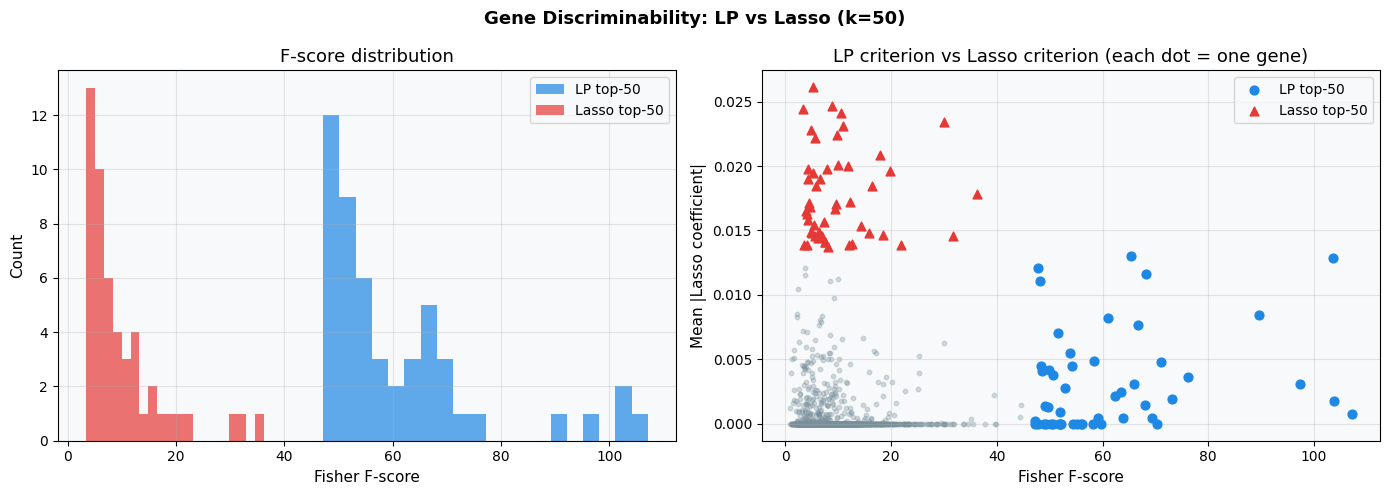

In [ ]:
# F-score distribution of the two top-k sets, and a scatter of the two ranking criteria
k = 50
lp_top    = np.argsort(f_scores)[::-1][:k]
lasso_top = lasso_rank[:k]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Gene Discriminability: LP vs Lasso (k={k})", fontsize=13, fontweight="bold")

axes[0].hist(f_scores[lp_top],    bins=20, color="#1E88E5", alpha=0.7, label="LP top-50")
axes[0].hist(f_scores[lasso_top], bins=20, color="#E53935", alpha=0.7, label="Lasso top-50")
axes[0].set(xlabel="Fisher F-score", ylabel="Count",
            title="F-score distribution"); axes[0].legend()

lasso_mag = np.abs(lasso_best.coef_).mean(axis=0)
sample = np.random.default_rng(0).choice(n_features, size=min(2000, n_features), replace=False)
axes[1].scatter(f_scores[sample], lasso_mag[sample], alpha=0.3, s=10, color="#78909C")
axes[1].scatter(f_scores[lp_top],    lasso_mag[lp_top],
                color="#1E88E5", s=40, label="LP top-50",     zorder=5)
axes[1].scatter(f_scores[lasso_top], lasso_mag[lasso_top],
                color="#E53935", s=40, label="Lasso top-50",  marker="^", zorder=5)
axes[1].set(xlabel="Fisher F-score", ylabel="Mean |Lasso coefficient|",
            title="LP criterion vs Lasso criterion (each dot = one gene)")
axes[1].legend()

plt.tight_layout()
plt.savefig(RES_DIR / "step6_gene_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 7 Final Summary

In [ ]:
print("=" * 70)
print("FINAL RESULTS")
print("=" * 70)

print("\nOptimizer ranking — mean across all schedules, regularizers, seeds:\n")
opt_summary = (df.groupby("optimizer")
                 [["val_acc", "test_acc", "test_f1", "train_time_s"]]
                 .mean().round(4)
                 .sort_values("val_acc", ascending=False))
opt_summary.columns = ["Val acc", "Test acc", "Test F1", "Time (s)"]
print(opt_summary.to_string())

print("\n" + "=" * 70)
print("LR schedule impact:\n")
print(df.groupby("lr_schedule")["val_acc"]
        .agg(["mean", "std"]).round(4)
        .sort_values("mean", ascending=False)
        .to_string())

print("\n" + "=" * 70)
print("Regularizer impact:\n")
print(df.groupby("regularizer")["val_acc"]
        .agg(["mean", "std"]).round(4)
        .to_string())

print("\n" + "=" * 70)
print(f"Files written to: {RES_DIR.resolve()}")
for f in sorted(os.listdir(RES_DIR)):
    sz = os.path.getsize(RES_DIR / f) / 1024
    print(f"  {f:<45} {sz:>8.1f} KB")

FINAL RESULTS

Optimizer ranking — mean across all schedules, regularizers, seeds:

                Val acc  Test acc  Test F1  Time (s)
optimizer                                           
L-BFGS           0.9373    0.9141   0.9071   13.1872
Mini-batch SGD   0.9360    0.9032   0.8957    1.3246
GD               0.9209    0.8872   0.8784    0.4324
SGD+Momentum     0.8817    0.8784   0.8746    1.3899
Adam             0.8779    0.8607   0.8505    1.5451
SGD              0.8439    0.8215   0.8081   31.1033

LR schedule impact:

                     mean     std
lr_schedule                      
Cosine Decay       0.9021  0.0415
Exponential Decay  0.9001  0.0398
Warm Restarts      0.8990  0.0408
Constant           0.8973  0.0440

Regularizer impact:

               mean     std
regularizer                
l1           0.9019  0.0402
l2           0.8973  0.0422

Files written to: /content/results
  eda_correlation.png                              161.1 KB
  eda_pca2d.png                     